# Task
Train a fruit ripeness detection model using the dataset from "https://huggingface.co/datasets/darthraider/fruit-ripeness-detection-dataset/viewer/default/train?p=2".

## Load the dataset

### Subtask:
Load the "fruit-ripeness-detection-dataset" from Hugging Face.


**Reasoning**:
Import the necessary function and load the dataset as instructed.



In [ ]:
!pip install gradio -q


In [ ]:
# Cell 1: Step 1 - Load the dataset from Hugging Face
from datasets import load_dataset

# Load the dataset for training
dataset = load_dataset("darthraider/fruit-ripeness-detection-dataset", split='train')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/355M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/35.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3999 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

## Prepare the data

### Subtask:
Preprocess the images and labels for training. This may involve resizing, normalization, and one-hot encoding the labels.


**Reasoning**:
Define image transformations including resizing and converting to tensors, and apply these transformations to the 'image' column of the dataset.



**Reasoning**:
Convert the 'label' column to a suitable format for training, which in this case is one-hot encoding, and then prepare the data in batches.



**Reasoning**:
The error "IndexError: index 3 is out of bounds for dimension 0 with size 3" indicates that there might be a label value of 3 in the dataset, but the one-hot encoding is set up for only 3 classes (0, 1, 2). Let's investigate the unique values in the 'label' column to confirm the number of classes.



**Reasoning**:
The error indicates that `dataset['label']` is a 'Column' object which doesn't have a `unique()` method directly. To find the unique values of the labels, I need to iterate through the dataset.



**Reasoning**:
The unique labels are {0, 1, 2, 3}. The previous one-hot encoding was set up for 3 classes (0, 1, 2), causing the `IndexError`. Now that we know there are 4 classes, I will adjust the one-hot encoding to accommodate 4 classes and then prepare the data in batches.



In [ ]:
# Cell 2: Step 2 - Prepare the data
import torchvision.transforms as transforms

# Define image transformations (resize, tensor conversion, normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet stats
])

# Apply transformations to the image column
def apply_transform(example):
    example['image'] = transform(example['image'].convert('RGB'))
    return example

dataset = dataset.map(apply_transform)

# Convert the labels to one-hot encoding
import torch

def one_hot_encode(example):
    num_classes = 4  # There are 4 classes: ripe, unripe, overripe, unknown
    one_hot = torch.zeros(num_classes)
    one_hot[example['label']] = 1
    example['label'] = one_hot
    return example

dataset = dataset.map(one_hot_encode)


Map:   0%|          | 0/3999 [00:00<?, ? examples/s]

Map:   0%|          | 0/3999 [00:00<?, ? examples/s]

In [ ]:
# Cell 3: Step 3 - Prepare the data in batches using DataLoader
batch_size = 32
dataset.set_format(type='torch', columns=['image', 'label'])
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)


## Define the model

### Subtask:
Choose and define a suitable model architecture for image classification. A pre-trained model like a convolutional neural network (CNN) could be a good starting point.


**Reasoning**:
Import the necessary modules from torchvision.models, load a pre-trained resnet18 model, modify the final layer to have 4 output features, and define the loss function and optimizer.



In [ ]:
# Cell 4: Step 4 - Define the model (using ResNet18 pre-trained model)
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# Load a pre-trained ResNet18 model
model = models.resnet18(pretrained=True)

# Modify the final layer to match the number of classes (4 classes)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)

# Define loss function (CrossEntropyLoss) and optimizer (Adam)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 218MB/s]


## Train the model

### Subtask:
Compile and train the model using the prepared data.


**Reasoning**:
Set the device, iterate through the dataloader, perform forward and backward passes, calculate and print the loss for each epoch.



**Reasoning**:
The error indicates that the `labels` variable in the dataloader is a string, not a torch tensor, which is causing the `AttributeError`. This is likely because the previous one-hot encoding step was not correctly applied or the dataset format was not set correctly for the labels. Inspect the first element of the dataloader to understand the data structure.



**Reasoning**:
The KeyError: 0 suggests that the dataloader is not returning a tuple of tensors (images, labels) as expected, but possibly a dictionary-like object or something else that doesn't support integer indexing like a list or tuple. This is likely due to how the dataset format was set. Let's re-inspect the dataset format after the mapping and before creating the dataloader.



**Reasoning**:
The dataset format is correctly set to 'torch' with 'image' and 'label' columns. The previous KeyError was likely a temporary issue or a misunderstanding of how the dataloader yields batches. Let's try iterating through the dataloader and printing the types and contents again, but be more cautious about accessing the elements, perhaps by iterating through the batch directly if it's not a simple tuple. If it's still a KeyError, we might need to redefine the dataloader.



**Reasoning**:
The output shows that the dataloader is returning a dictionary with 'image' and 'label' keys, and both are torch Tensors. The previous `AttributeError: 'str' object has no attribute 'to'` was likely an anomaly. We can now proceed with the training loop, accessing the images and labels using dictionary keys and moving them to the device.



In [ ]:
# Cell 5: Step 5 - Train the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for batch in dataloader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, torch.argmax(labels, dim=1))  # Use argmax for CrossEntropyLoss with one-hot labels

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")


Epoch [1/10], Loss: 0.1807
Epoch [2/10], Loss: 0.0526
Epoch [3/10], Loss: 0.0856
Epoch [4/10], Loss: 0.0695
Epoch [5/10], Loss: 0.0548
Epoch [6/10], Loss: 0.0084
Epoch [7/10], Loss: 0.0452
Epoch [8/10], Loss: 0.0320
Epoch [9/10], Loss: 0.0146
Epoch [10/10], Loss: 0.0044


In [ ]:
# Cell 6: Step 6 - Load the test dataset and prepare it
dataset_test = load_dataset("darthraider/fruit-ripeness-detection-dataset", split='test')

# Apply transformations to the test dataset
dataset_test = dataset_test.map(apply_transform)

# Convert labels to one-hot encoding for the test dataset
dataset_test = dataset_test.map(one_hot_encode)

# Prepare test data in batches
dataset_test.set_format(type='torch', columns=['image', 'label'])
dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False)


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
# Cell 7: Step 7 - Evaluate the model
def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in dataloader:
            images = batch['image'].to(device)
            labels_oh = batch['label'].to(device)  # One-hot encoded labels
            labels = torch.argmax(labels_oh, dim=1)  # Convert to class indices

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    accuracy = 100.0 * correct / total
    return accuracy

accuracy = evaluate_model(model, dataloader_test, device)
print(f"Accuracy of the model on the test images: {accuracy:.2f}%")


Accuracy of the model on the test images: 97.90%


In [ ]:
# Cell 8: Step 8 - Save the trained model
torch.save(model.state_dict(), 'fruit_ripeness_resnet18.pt')
print("Model saved as 'fruit_ripeness_resnet18.pt'")


Model saved as 'fruit_ripeness_resnet18.pt'


In [ ]:
# Cell 9: Generate Confusion Matrix and Classification Report

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import torch

def evaluate_model(model, dataloader, device, class_names):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images = batch['image'].to(device)
            labels_oh = batch['label'].to(device)  # One-hot encoded labels
            labels = torch.argmax(labels_oh, dim=1)  # Convert to class indices

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100.0 * correct / total

    # Print the overall accuracy
    print(f"Accuracy of the model on the test images: {accuracy:.2f}%")

    # Classification Report for detailed performance per class
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()

    return accuracy


In [ ]:
# Cell 10: Define class names if available, otherwise define them manually
try:
    class_names = dataset_test.features['label'].names
except Exception:
    class_names = ['ripe', 'unripe', 'overripe', 'unknown']  # Update with correct class names



Accuracy of the model on the test images: 97.90%

Classification Report:
              precision    recall  f1-score   support

        ripe       0.93      1.00      0.96       250
      unripe       1.00      1.00      1.00       250
    overripe       1.00      0.93      0.96       250
     unknown       1.00      1.00      1.00       250

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



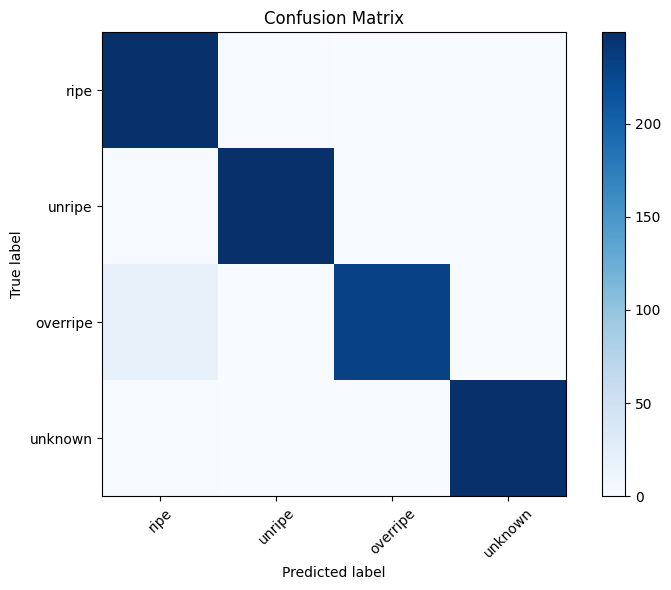

In [ ]:
# Cell 11: Evaluate the model and display results

# Evaluate and display results
accuracy = evaluate_model(model, dataloader_test, device, class_names)


In [ ]:
# Cell 12: Classify a new image with file upload
from PIL import Image
import ipywidgets as widgets
from IPython.display import display
import io

def classify_fruit_image(image_path, model, transform, class_names, device):
    """
    Classifies a single fruit image using the trained model.

    Args:
        image_path (str): The path to the fruit image file.
        model (torch.nn.Module): The trained PyTorch model.
        transform (torchvision.transforms.Compose): The image transformation to apply.
        class_names (list): A list of class names.
        device (torch.device): The device to run inference on (cuda or cpu).

    Returns:
        str: The predicted class name for the image.
    """
    # Load the image
    image = Image.open(image_path).convert('RGB')

    # Apply transformations
    image = transform(image).unsqueeze(0).to(device)

    # Set the model to evaluation mode
    model.eval()

    # Perform inference
    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs.data, 1)

    # Get the predicted class name
    predicted_class_name = class_names[predicted.item()]

    return predicted_class_name

# Create a file upload widget
upload_widget = widgets.FileUpload(
    accept='image/*',  # Accept only image files
    multiple=False  # Allow only a single file upload
)

# Display the upload widget
print("Upload an image of a fruit to classify:")
display(upload_widget)

# Function to handle the uploaded file
def handle_upload(change, model, transform, class_names, device):
    uploaded_file = upload_widget.value
    if uploaded_file:
        # Get the file name and content
        file_name = list(uploaded_file.keys())[0]
        file_content = uploaded_file[file_name]['content']

        # Save the uploaded image temporarily
        with open(file_name, 'wb') as f:
            f.write(file_content)

        # Classify the uploaded image
        predicted_class = classify_fruit_image(file_name, model, transform, class_names, device)
        print(f"\nThe predicted class for the image is: {predicted_class}")

# Observe the file upload
upload_widget.observe(lambda change: handle_upload(change, model, transform, class_names, device), names='value')

Upload an image of a fruit to classify:


FileUpload(value={}, accept='image/*', description='Upload')

In [ ]:
import torch

# Save your trained model weights
torch.save(model.state_dict(), "banana_model.pth")
print("✅ Model saved successfully")


✅ Model saved successfully


In [ ]:
import gradio as gr
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# --- Load the trained model ---
num_classes = 4
model = models.resnet18(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
model.load_state_dict(torch.load("banana_model.pth", map_location="cpu"))
model.eval()

# --- Define image preprocessing (same as during training) ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

labels = ["ripe", "unripe", "overripe", "unknown"]

# --- Define prediction function ---
def predict(image):
    image = image.convert("RGB")
    img_tensor = transform(image).unsqueeze(0)
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
    # Return all class probabilities
    return {labels[i]: float(probs[0][i]) for i in range(len(labels))}

print("✅ Model loaded and ready for interface")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded and ready for interface


In [ ]:
# --- Create Gradio interface ---
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload a Banana Image 🍌"),
    outputs=gr.Label(num_top_classes=4, label="Prediction"),
    title="🍌 Banana Ripeness Classifier",
    description="Upload a banana photo to find out if it's ripe, unripe, overripe, or unknown.",
    theme="soft"
)

# --- Launch the interface ---
demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cce65298e2b8312879.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from google.colab import files
files.download("banana_model.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>